In [1]:
!pip -q install -U transformers accelerate captum lime shap scipy scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 127.4 MB/s eta 0:00:00


In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from google.colab import drive

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/My Work/Research/Chaos/Code-mixed Chaos  Multi-labeled Banglish & Bangla/Code-mixed Chaos  Multi-labeled Banglish & Bangla"

MBERT_MODEL = os.path.join(BASE_PATH,"trained_bert_model")

XLMR_MODEL = os.path.join(BASE_PATH,"trained_xlmr_model")

BANGLA_DATA = os.path.join(BASE_PATH,"Bangla.xlsx")

BANGLISH_DATA = os.path.join(BASE_PATH,"Banglish.xlsx")

In [5]:
LABEL_COLS = [

    "Vulgar-based",

    "Religious-Hostility",

    "Troll-based",

    "Insult-based",

    "Loathe-based",

    "Threat-based",

    "Race-based",

    "Humilaton-Based",

    "Political-Chaos",

    "Non-Toxic"
]

In [6]:
bangla = pd.read_excel(BANGLA_DATA)

banglish = pd.read_excel(BANGLISH_DATA)

df = pd.concat(
    [bangla,banglish],
    ignore_index=True
)

print(df.shape)
df.head()

(20468, 11)


,Text,Vulgar-based,Religious-Hostility,Troll-based,Insult-based,Loathe-based,Threat-based,Race-based,Sexual-based,Political-Chaos,Non-Toxic
0,ইউসুফ সরকারকে এর চরম মূল্য দিতে হবে🤪,0,0,1,0,0,0,0,0,1,0
1,"হাসিনা ইজ লাইক আওয়ার বাঙ্গালী বয়ফ্রেইন্ড, মানু...",0,0,1,1,0,0,0,0,1,0
2,হাসিনা সরকার প্রমান করে যে মেয়েরা কখনো তাদের দ...,0,0,1,0,0,0,0,0,1,0
3,আপু তোমার কি হ্যান্ড এমব্রয়ডারি ফ্রি সিরিজ ইউট...,0,0,0,0,0,0,0,0,0,1
4,"ভাই এর লজিক টাইটানিক এর লাইফ জ্যাকেট এর মতো, দ...",0,0,1,1,0,0,0,0,0,0


In [7]:
df = df.rename(
    columns={
        "Sexual-based":"Humilaton-Based"
    }
)

In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(

    df,

    test_size=0.15,

    random_state=42,

    shuffle=True

)

print(test_df.shape)

(3071, 11)


In [9]:
texts = test_df["Text"].tolist()

y_true = test_df[LABEL_COLS].values

print(len(texts))

3071


In [10]:
mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_MODEL)

mbert = AutoModelForSequenceClassification.from_pretrained(
    MBERT_MODEL
)

mbert.to(device)

mbert.eval()

print("Loaded mBERT")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Loaded mBERT


In [11]:
xlmr_tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL)

xlmr = AutoModelForSequenceClassification.from_pretrained(
    XLMR_MODEL
)

xlmr.to(device)

xlmr.eval()

print("Loaded XLM-R")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded XLM-R


In [12]:
from torch.utils.data import DataLoader

def predict_dataset(model,
                    tokenizer,
                    texts,
                    batch_size=32,
                    max_length=192):

    probs_all = []

    model.eval()

    for start in range(0, len(texts), batch_size):

        batch = texts[start:start+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        enc = {k:v.to(device) for k,v in enc.items()}

        with torch.no_grad():

            logits = model(**enc).logits

            probs = torch.sigmoid(logits)

        probs_all.append(probs.cpu())

    probs_all = torch.cat(probs_all)

    return probs_all.numpy()

In [13]:
mbert_probs = predict_dataset(

    mbert,

    mbert_tokenizer,

    texts,

    batch_size=32

)

print(mbert_probs.shape)

(3071, 10)


In [14]:
xlmr_probs = predict_dataset(

    xlmr,

    xlmr_tokenizer,

    texts,

    batch_size=32

)

print(xlmr_probs.shape)

(3071, 10)


In [15]:
THRESHOLD = 0.5

mbert_preds = (mbert_probs >= THRESHOLD).astype(int)

xlmr_preds = (xlmr_probs >= THRESHOLD).astype(int)

print(mbert_preds.shape)

print(xlmr_preds.shape)

(3071, 10)
(3071, 10)


In [16]:
np.save("mbert_probs.npy",mbert_probs)

np.save("xlmr_probs.npy",xlmr_probs)

np.save("mbert_preds.npy",mbert_preds)

np.save("xlmr_preds.npy",xlmr_preds)

np.save("y_true.npy",y_true)

print("Saved.")

Saved.


Confidence Score

In [17]:
mbert_confidence = np.max(
    mbert_probs,
    axis=1
)

xlmr_confidence = np.max(
    xlmr_probs,
    axis=1
)

print(mbert_confidence[:10])

[0.93380773 0.98872095 0.8478203  0.990738   0.98964256 0.98763496
 0.90343565 0.89562696 0.8755207  0.5037934 ]


Predicyive Entropy

In [18]:
def predictive_entropy(probs):

    eps = 1e-12

    probs = np.clip(probs,eps,1-eps)

    entropy = -np.sum(

        probs*np.log(probs)

        +(1-probs)*np.log(1-probs),

        axis=1

    )

    return entropy

In [19]:
mbert_entropy = predictive_entropy(mbert_probs)

xlmr_entropy = predictive_entropy(xlmr_probs)

print(mbert_entropy[:10])

print(xlmr_entropy[:10])

[3.4565408  0.3088919  3.3174088  0.31003428 0.3084263  0.33902058
 3.82546    2.2821853  3.051231   2.244592  ]
[2.8494284  0.31448454 3.4661062  0.30911818 0.31546277 0.6829548
 3.9265585  3.2993996  3.9931972  0.5422914 ]


In [20]:
np.save(
    "mbert_entropy.npy",
    mbert_entropy
)

np.save(
    "xlmr_entropy.npy",
    xlmr_entropy
)

MC Dropout

In [21]:
import torch.nn as nn

def enable_dropout(model):
    """
    Enable dropout layers during inference.
    """
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

In [22]:
def mc_dropout_predict(
    model,
    tokenizer,
    texts,
    T=30,
    batch_size=32,
    max_length=192
):

    enable_dropout(model)

    predictions = []

    for t in range(T):

        probs_all = []

        for start in range(0, len(texts), batch_size):

            batch = texts[start:start+batch_size]

            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            enc = {
                k:v.to(device)
                for k,v in enc.items()
            }

            with torch.no_grad():

                logits = model(**enc).logits

                probs = torch.sigmoid(logits)

            probs_all.append(
                probs.cpu().numpy()
            )

        probs_all = np.concatenate(
            probs_all,
            axis=0
        )

        predictions.append(probs_all)

        print(f"MC Pass {t+1}/{T}")

    predictions = np.stack(predictions)

    return predictions

In [23]:
mc_mbert = mc_dropout_predict(

    mbert,

    mbert_tokenizer,

    texts,

    T=30,

    batch_size=32

)

print(mc_mbert.shape)

MC Pass 1/30
MC Pass 2/30
MC Pass 3/30
MC Pass 4/30
MC Pass 5/30
MC Pass 6/30
MC Pass 7/30
MC Pass 8/30
MC Pass 9/30
MC Pass 10/30
MC Pass 11/30
MC Pass 12/30
MC Pass 13/30
MC Pass 14/30
MC Pass 15/30
MC Pass 16/30
MC Pass 17/30
MC Pass 18/30
MC Pass 19/30
MC Pass 20/30
MC Pass 21/30
MC Pass 22/30
MC Pass 23/30
MC Pass 24/30
MC Pass 25/30
MC Pass 26/30
MC Pass 27/30
MC Pass 28/30
MC Pass 29/30
MC Pass 30/30
(30, 3071, 10)


In [25]:
mc_xlmr = mc_dropout_predict(

    xlmr,

    xlmr_tokenizer,

    texts,

    T=30,

    batch_size=32

)

print(mc_xlmr.shape)

MC Pass 1/30
MC Pass 2/30
MC Pass 3/30
MC Pass 4/30
MC Pass 5/30
MC Pass 6/30
MC Pass 7/30
MC Pass 8/30
MC Pass 9/30
MC Pass 10/30
MC Pass 11/30
MC Pass 12/30
MC Pass 13/30
MC Pass 14/30
MC Pass 15/30
MC Pass 16/30
MC Pass 17/30
MC Pass 18/30
MC Pass 19/30
MC Pass 20/30
MC Pass 21/30
MC Pass 22/30
MC Pass 23/30
MC Pass 24/30
MC Pass 25/30
MC Pass 26/30
MC Pass 27/30
MC Pass 28/30
MC Pass 29/30
MC Pass 30/30
(30, 3071, 10)


In [26]:
mbert_mean = mc_mbert.mean(axis=0)

xlmr_mean = mc_xlmr.mean(axis=0)

In [27]:
mbert_variance = mc_mbert.var(axis=0)

xlmr_variance = mc_xlmr.var(axis=0)

In [28]:
mbert_uncertainty = np.mean(
    mbert_variance,
    axis=1
)

xlmr_uncertainty = np.mean(
    xlmr_variance,
    axis=1
)

print(mbert_uncertainty.shape)

(3071,)


In [29]:
np.save(
    "mbert_uncertainty.npy",
    mbert_uncertainty
)

np.save(
    "xlmr_uncertainty.npy",
    xlmr_uncertainty
)

print("Saved MC Dropout uncertainty.")

Saved MC Dropout uncertainty.


In [30]:
print("===== mBERT =====")

print("Mean :", np.mean(mbert_uncertainty))

print("Std  :", np.std(mbert_uncertainty))

print()

print("===== XLM-R =====")

print("Mean :", np.mean(xlmr_uncertainty))

print("Std  :", np.std(xlmr_uncertainty))

===== mBERT =====
Mean : 0.002460913
Std  : 0.0045559583

===== XLM-R =====
Mean : 0.0026323549
Std  : 0.004520586


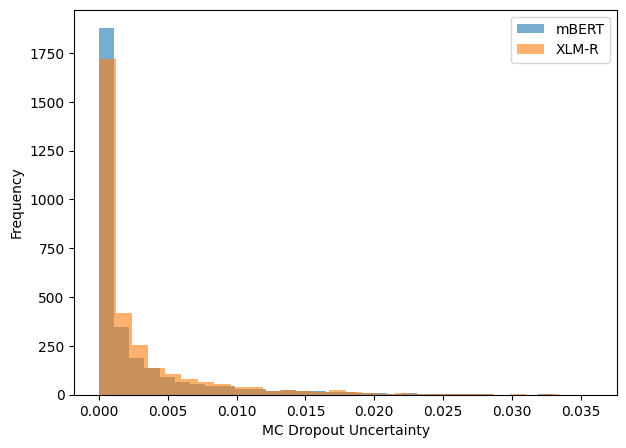

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(
    mbert_uncertainty,
    bins=30,
    alpha=0.6,
    label="mBERT"
)

plt.hist(
    xlmr_uncertainty,
    bins=30,
    alpha=0.6,
    label="XLM-R"
)

plt.xlabel("MC Dropout Uncertainty")

plt.ylabel("Frequency")

plt.legend()

plt.show()

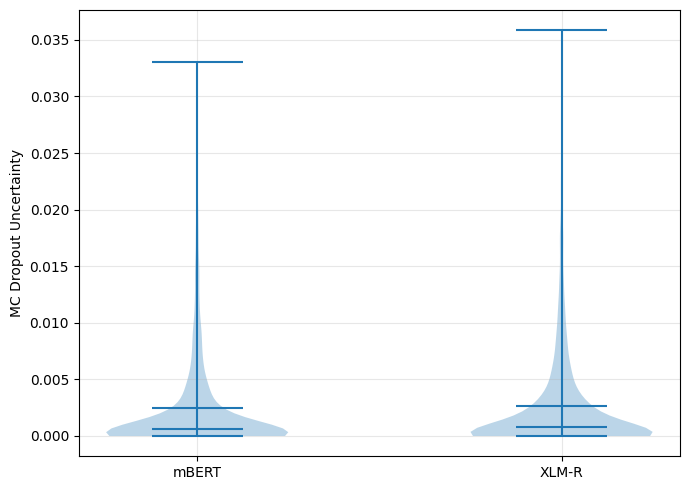

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.violinplot(
    [mbert_uncertainty, xlmr_uncertainty],
    showmeans=True,
    showmedians=True
)

plt.xticks([1,2], ["mBERT","XLM-R"])

plt.ylabel("MC Dropout Uncertainty")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

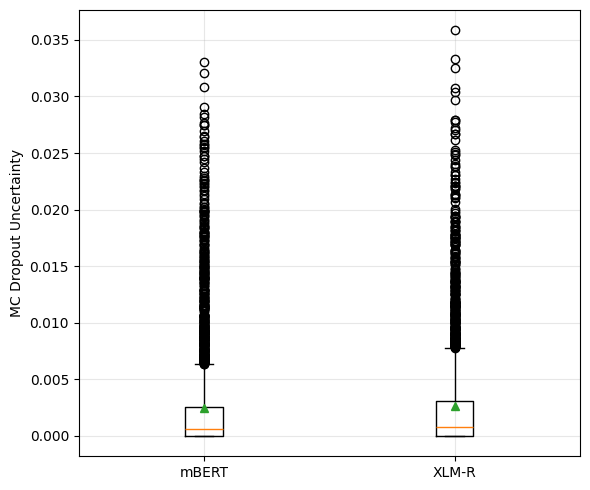

In [33]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [mbert_uncertainty,
     xlmr_uncertainty],
    labels=["mBERT","XLM-R"],
    showmeans=True
)

plt.ylabel("MC Dropout Uncertainty")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

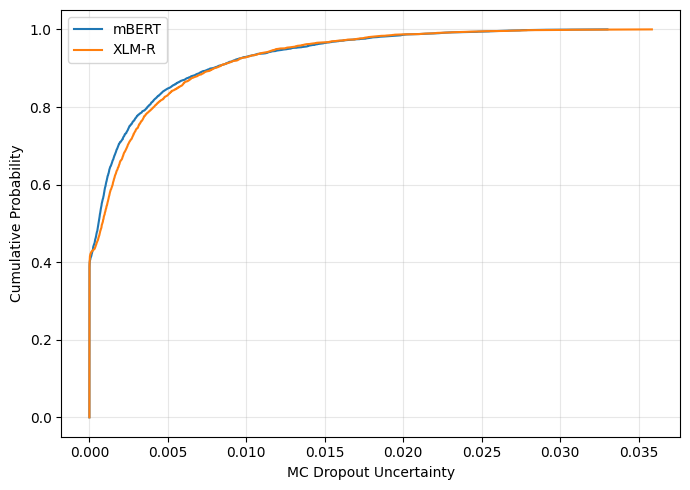

In [34]:
plt.figure(figsize=(7,5))

for data,label in zip(
    [mbert_uncertainty,xlmr_uncertainty],
    ["mBERT","XLM-R"]
):

    x=np.sort(data)

    y=np.arange(1,len(x)+1)/len(x)

    plt.plot(x,y,label=label)

plt.xlabel("MC Dropout Uncertainty")

plt.ylabel("Cumulative Probability")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

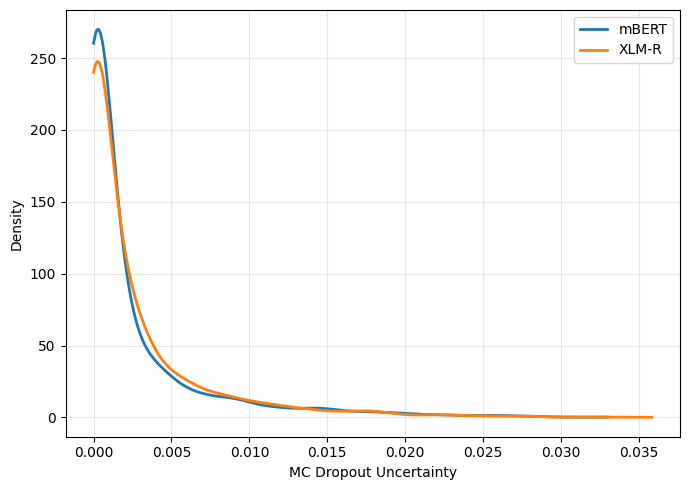

In [35]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(7,5))

for data,label in zip(
    [mbert_uncertainty,xlmr_uncertainty],
    ["mBERT","XLM-R"]
):

    density=gaussian_kde(data)

    xs=np.linspace(data.min(),data.max(),300)

    plt.plot(xs,density(xs),linewidth=2,label=label)

plt.xlabel("MC Dropout Uncertainty")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [36]:
!pip -q install captum

In [37]:
from captum.attr import LayerIntegratedGradients
import torch
import numpy as np

In [38]:
def forward_func(
    input_ids,
    attention_mask
):

    outputs = mbert(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits

In [39]:
lig = LayerIntegratedGradients(
    forward_func,
    mbert.bert.embeddings
)

In [40]:
from captum.attr import LayerIntegratedGradients

# mBERT
lig_mbert = LayerIntegratedGradients(
    lambda input_ids, attention_mask:
        mbert(input_ids=input_ids,
              attention_mask=attention_mask).logits,
    mbert.bert.embeddings
)

# XLM-R
lig_xlmr = LayerIntegratedGradients(
    lambda input_ids, attention_mask:
        xlmr(input_ids=input_ids,
             attention_mask=attention_mask).logits,
    xlmr.roberta.embeddings
)

In [41]:
import numpy as np

def explanation_concentration(attribution):

    token_scores = attribution.abs().sum(dim=-1)

    token_scores = token_scores.squeeze(0)

    token_scores = token_scores.detach().cpu().numpy()

    token_scores /= (token_scores.sum() + 1e-12)

    return token_scores.max()

In [42]:
import numpy as np

def explanation_concentration(attribution):

    token_scores = attribution.abs().sum(dim=-1)

    token_scores = token_scores.squeeze(0)

    token_scores = token_scores.detach().cpu().numpy()

    token_scores /= (token_scores.sum() + 1e-12)

    return token_scores.max()

In [43]:
def compute_ec_scores(
    model,
    tokenizer,
    lig,
    texts,
    max_length=192
):

    ec_scores = []

    model.eval()

    for idx, text in enumerate(texts):

        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        )

        input_ids = enc["input_ids"].to(device)

        attention_mask = enc["attention_mask"].to(device)

        with torch.no_grad():

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

        probs = torch.sigmoid(logits)

        sample_ec = []

        # Compute IG for all labels
        for label in range(len(LABEL_COLS)):

            if probs[0, label] < 0.5:
                continue

            attr = lig.attribute(
                inputs=input_ids,
                additional_forward_args=(attention_mask,),
                target=label,
                n_steps=20
            )

            ec = explanation_concentration(attr)

            sample_ec.append(ec)

        if len(sample_ec) == 0:
            sample_ec.append(0)

        ec_scores.append(np.mean(sample_ec))

        if (idx + 1) % 100 == 0:
            print(f"{idx+1}/{len(texts)}")

    return np.array(ec_scores)

In [44]:
mbert_ec = compute_ec_scores(
    mbert,
    mbert_tokenizer,
    lig_mbert,
    texts
)

print(mbert_ec.shape)

100/3071
200/3071
300/3071
400/3071
500/3071
600/3071
700/3071
800/3071
900/3071
1000/3071
1100/3071
1200/3071
1300/3071
1400/3071
1500/3071
1600/3071
1700/3071
1800/3071
1900/3071
2000/3071
2100/3071
2200/3071
2300/3071
2400/3071
2500/3071
2600/3071
2700/3071
2800/3071
2900/3071
3000/3071
(3071,)


In [45]:
xlmr_ec = compute_ec_scores(
    xlmr,
    xlmr_tokenizer,
    lig_xlmr,
    texts
)

print(xlmr_ec.shape)

100/3071
200/3071
300/3071
400/3071
500/3071
600/3071
700/3071
800/3071
900/3071
1000/3071
1100/3071
1200/3071
1300/3071
1400/3071
1500/3071
1600/3071
1700/3071
1800/3071
1900/3071
2000/3071
2100/3071
2200/3071
2300/3071
2400/3071
2500/3071
2600/3071
2700/3071
2800/3071
2900/3071
3000/3071
(3071,)


In [46]:
np.save("mbert_ec.npy", mbert_ec)

np.save("xlmr_ec.npy", xlmr_ec)

In [47]:
from scipy.stats import spearmanr

rho_mbert, p_mbert = spearmanr(
    mbert_uncertainty,
    mbert_ec
)

rho_xlmr, p_xlmr = spearmanr(
    xlmr_uncertainty,
    xlmr_ec
)

print("mBERT")
print(rho_mbert, p_mbert)

print()

print("XLM-R")
print(rho_xlmr, p_xlmr)

mBERT
0.16799238968820152 7.086249273332481e-21

XLM-R
-0.018509990550456934 0.3051598371663159


In [48]:
results = pd.DataFrame({

    "Model":[
        "mBERT",
        "XLM-R"
    ],

    "Spearman_rho":[
        rho_mbert,
        rho_xlmr
    ],

    "P_value":[
        p_mbert,
        p_xlmr
    ]

})

results

,Model,Spearman_rho,P_value
0,mBERT,0.167992,7.086249e-21
1,XLM-R,-0.018510,3.051598e-01


In [49]:
results.to_csv(
    "Spearman_results.csv",
    index=False
)

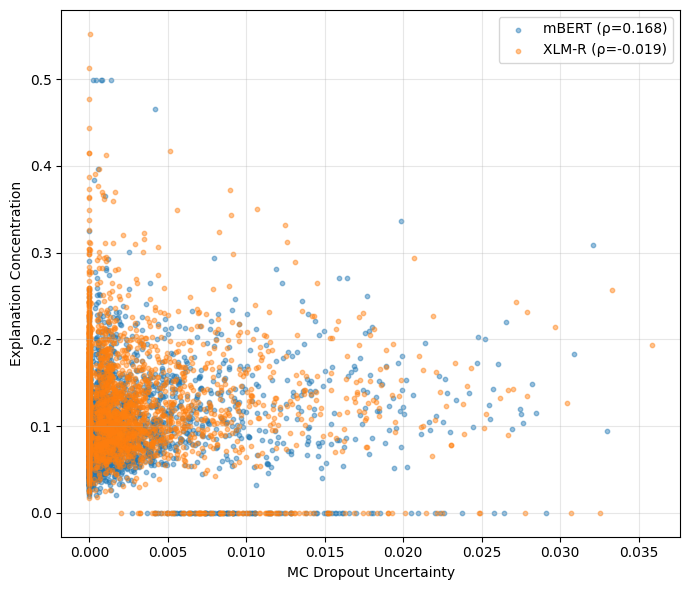

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    mbert_uncertainty,
    mbert_ec,
    s=10,
    alpha=0.45,
    label=f"mBERT (ρ={rho_mbert:.3f})"
)

plt.scatter(
    xlmr_uncertainty,
    xlmr_ec,
    s=10,
    alpha=0.45,
    label=f"XLM-R (ρ={rho_xlmr:.3f})"
)

plt.xlabel("MC Dropout Uncertainty")

plt.ylabel("Explanation Concentration")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

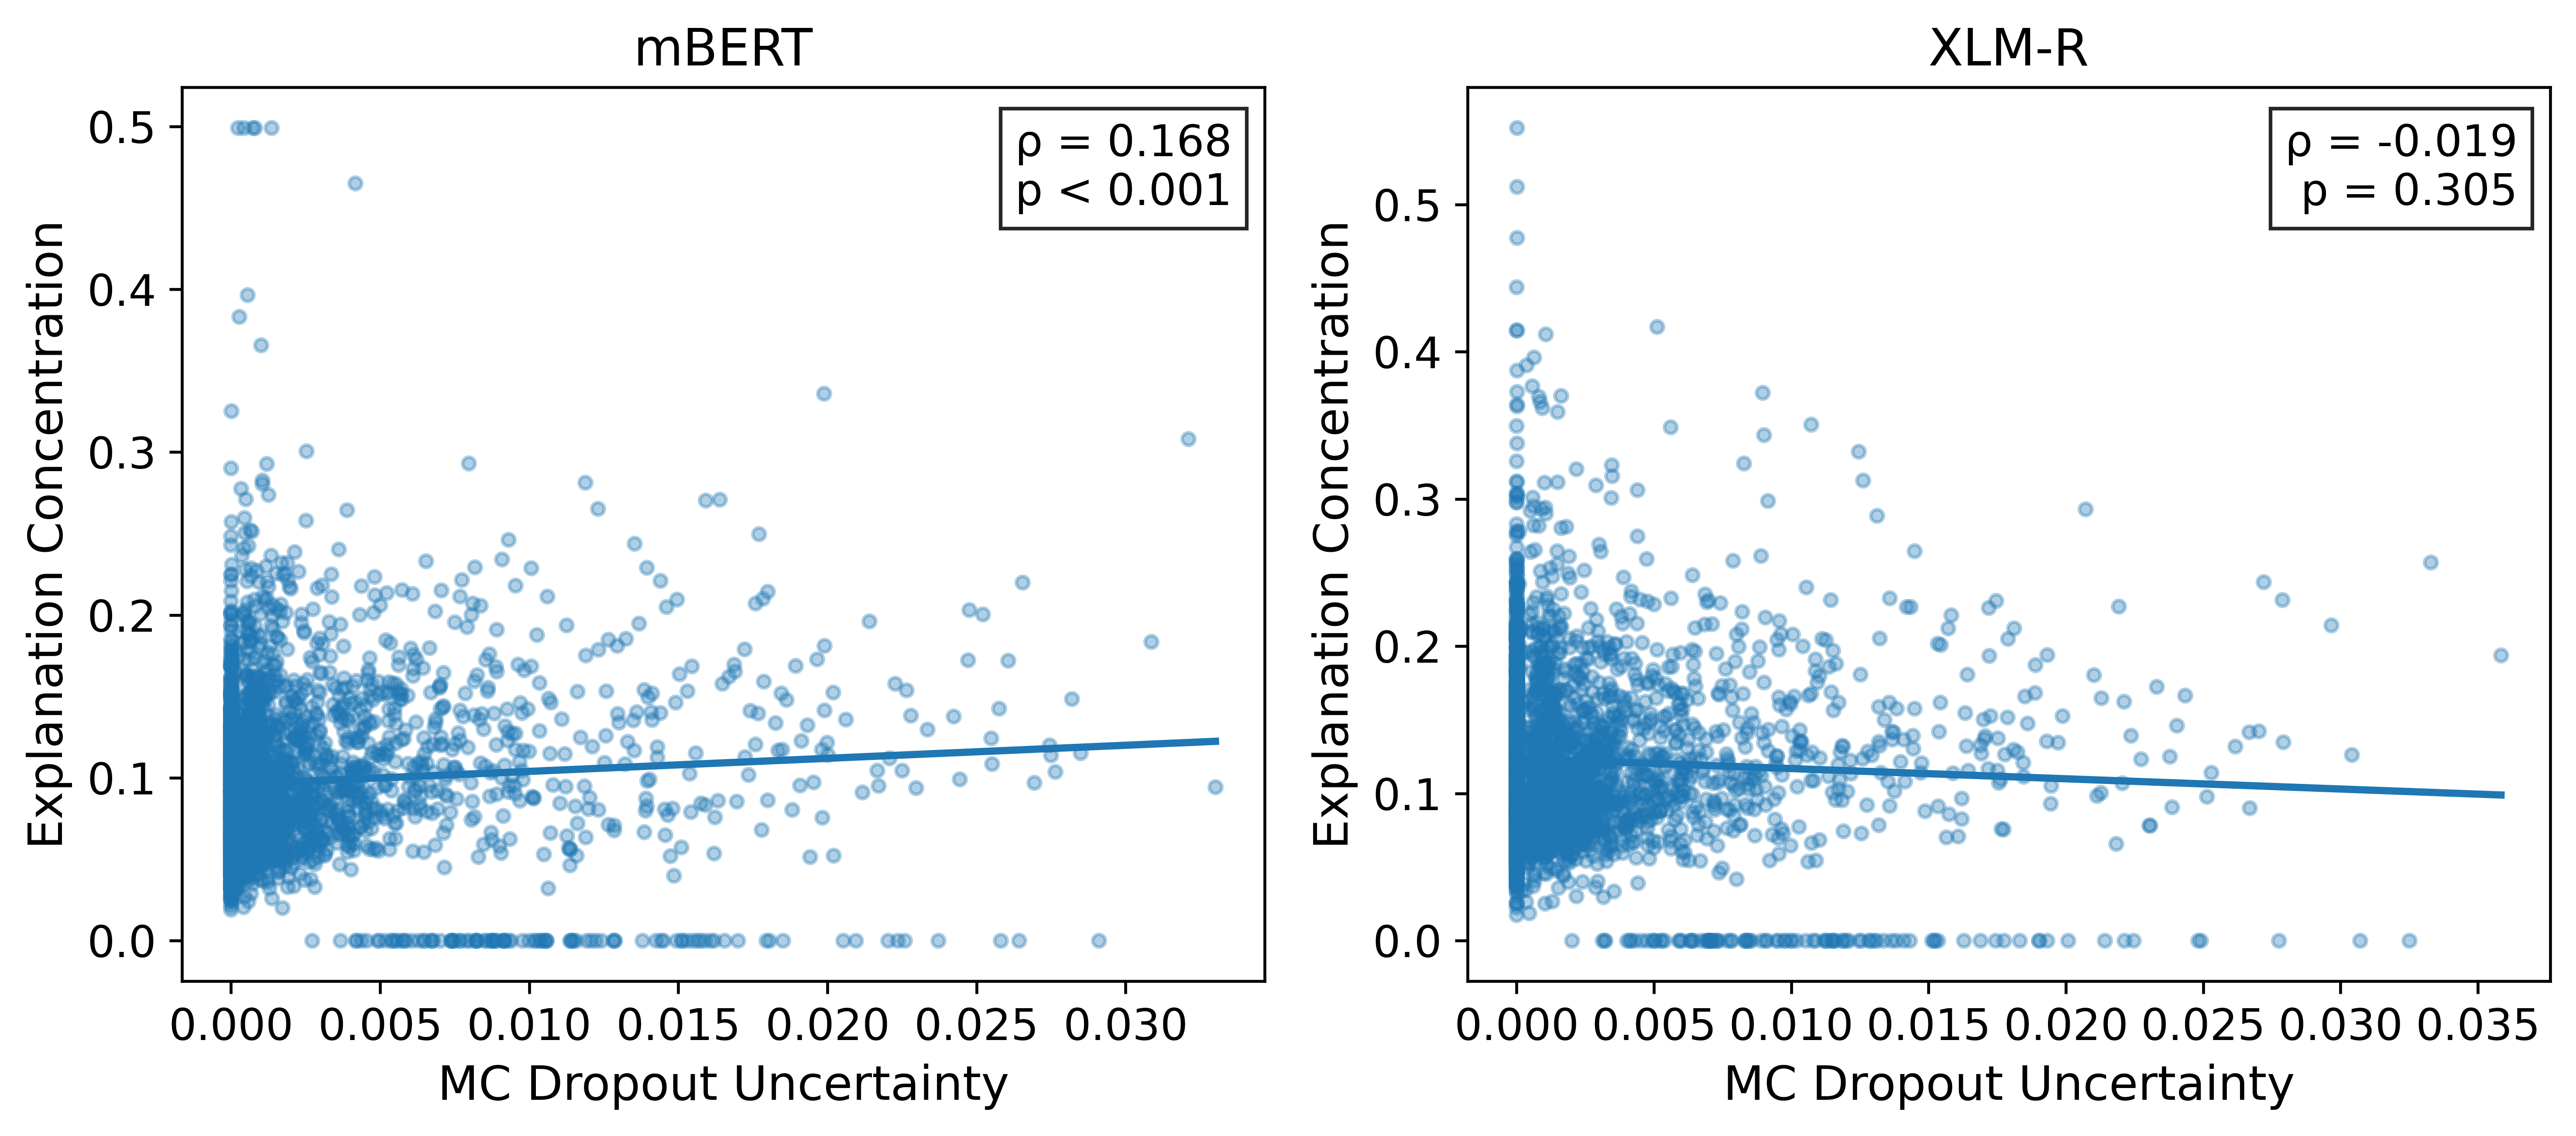

In [54]:
rho_m, p_m = spearmanr(mbert_uncertainty, mbert_ec)
rho_x, p_x = spearmanr(xlmr_uncertainty, xlmr_ec)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

fig, axes = plt.subplots(1, 2, figsize=(10,4.5), dpi=600)

# ==========================
# mBERT
# ==========================
axes[0].scatter(
    mbert_uncertainty,
    mbert_ec,
    s=12,
    alpha=0.35
)

coef = np.polyfit(mbert_uncertainty,
                  mbert_ec,
                  1)

x = np.linspace(
    np.min(mbert_uncertainty),
    np.max(mbert_uncertainty),
    200
)

axes[0].plot(
    x,
    coef[0]*x + coef[1],
    linewidth=2
)

axes[0].set_title("mBERT")
axes[0].set_xlabel("MC Dropout Uncertainty")
axes[0].set_ylabel("Explanation Concentration")

axes[0].text(
    0.97,
    0.96,
    f"ρ = {rho_m:.3f}\np < 0.001",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white",
              alpha=0.85)
)

# ==========================
# XLM-R
# ==========================
axes[1].scatter(
    xlmr_uncertainty,
    xlmr_ec,
    s=12,
    alpha=0.35
)

coef = np.polyfit(
    xlmr_uncertainty,
    xlmr_ec,
    1
)

x = np.linspace(
    np.min(xlmr_uncertainty),
    np.max(xlmr_uncertainty),
    200
)

axes[1].plot(
    x,
    coef[0]*x + coef[1],
    linewidth=2
)

axes[1].set_title("XLM-R")
axes[1].set_xlabel("MC Dropout Uncertainty")
axes[1].set_ylabel("Explanation Concentration")

axes[1].text(
    0.97,
    0.96,
    f"ρ = {rho_x:.3f}\np = {p_x:.3f}",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white",
              alpha=0.85)
)

plt.tight_layout()

plt.savefig(
    "uncertainty_vs_explanation.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "uncertainty_vs_explanation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [55]:
from sklearn.calibration import calibration_curve

def calculate_ece_mce_brier(y_true_labels, y_prob_predictions, num_bins=10):
    ece_scores = []
    mce_scores = []
    brier_scores = []

    # For multi-label classification, we can calculate metrics per label and average
    num_labels = y_true_labels.shape[1]

    for i in range(num_labels):
        y_true_label = y_true_labels[:, i]
        y_prob_label = y_prob_predictions[:, i]

        # Brier Score
        brier_scores.append(np.mean((y_prob_label - y_true_label)**2))

        # Expected Calibration Error (ECE) and Maximum Calibration Error (MCE)
        # Using sklearn's calibration_curve to get fraction of positives and mean predicted value
        prob_true, prob_pred = calibration_curve(
            y_true_label,
            y_prob_label,
            n_bins=num_bins,
            strategy='uniform' # or 'quantile'
        )

        # Initialize ECE and MCE for this label
        current_ece = 0.0
        current_mce = 0.0

        # Calculate bin widths and number of samples in each bin
        bin_low_edges = np.linspace(0, 1, num_bins + 1)[:-1]
        bin_high_edges = np.linspace(0, 1, num_bins + 1)[1:]

        for j in range(num_bins):
            # Filter predictions and true labels for the current bin
            in_bin = (y_prob_label >= bin_low_edges[j]) & (y_prob_label < bin_high_edges[j])
            if j == num_bins - 1: # Include 1.0 in the last bin
                in_bin = (y_prob_label >= bin_low_edges[j]) & (y_prob_label <= bin_high_edges[j])

            bin_true = y_true_label[in_bin]
            bin_prob = y_prob_label[in_bin]

            if len(bin_true) > 0:
                avg_accuracy = np.mean(bin_true)  # Fraction of positives
                avg_confidence = np.mean(bin_prob) # Mean predicted value

                # Calculate ECE part for this bin
                weight = len(bin_true) / len(y_true_label)
                current_ece += weight * np.abs(avg_accuracy - avg_confidence)

                # Calculate MCE part for this bin
                current_mce = max(current_mce, np.abs(avg_accuracy - avg_confidence))

        ece_scores.append(current_ece)
        mce_scores.append(current_mce)

    # Average metrics across all labels
    avg_ece = np.mean(ece_scores)
    avg_mce = np.mean(mce_scores)
    avg_brier = np.mean(brier_scores)

    return avg_ece, avg_mce, avg_brier

# Calculate metrics for mBERT
mbert_ece, mbert_mce, mbert_brier = calculate_ece_mce_brier(
    y_true,
    mbert_probs
)

# Calculate metrics for XLM-R
xlmr_ece, xlmr_mce, xlmr_brier = calculate_ece_mce_brier(
    y_true,
    xlmr_probs
)

print("mBERT Calibration Metrics:")
print(f"  ECE: {mbert_ece:.4f}")
print(f"  MCE: {mbert_mce:.4f}")
print(f"  Brier Score: {mbert_brier:.4f}")
print("\nXLM-R Calibration Metrics:")
print(f"  ECE: {xlmr_ece:.4f}")
print(f"  MCE: {xlmr_mce:.4f}")
print(f"  Brier Score: {xlmr_brier:.4f}")

mBERT Calibration Metrics:
  ECE: 0.0163
  MCE: 0.1925
  Brier Score: 0.0542

XLM-R Calibration Metrics:
  ECE: 0.0143
  MCE: 0.2789
  Brier Score: 0.0524
